# MNIST Denoiser with Autoencoder

## Getting the Dataset

### Importing Modules

In [35]:
import torch
from torch import nn
from torch.utils.data import Dataset, random_split, DataLoader, ConcatDataset
from torchvision import transforms
from torchvision.datasets import MNIST

import numpy as np

### Setting Up Variables

In [3]:
# Eğer CUDA varsa modeli eğitirken GPU'yu kullanacağız, yoksa CPU'yu.
device = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

BATCH_SIZE = 64
LEARNING_RATE = 1e-3
EPOCHS = 10
NOISE_FACTOR = 0.5

Device: cuda


### Downloading or Loading the Raw MNIST Dataset

In [ ]:
# MNIST training dataset'ini PyTorch'un kullanabileceği uygun formata dönüştürerek indiriyoruz
# veya zaten indirmişsek yüklüyoruz.
mnist_train = MNIST(root="data", train=True, download=True, transform=transforms.ToTensor())

# Training dataset'in bir kısmını validation için ayırıyoruz.
mnist_train, mnist_validation = random_split(mnist_train, [40000, 20000])

# Test dataset'i indiriyoruz.
mnist_test = MNIST(root="data", train=False, download=True, transform=transforms.ToTensor())

print(f'Training dataset size: {len(mnist_train)}')
print(f'Validation dataset size: {len(mnist_validation)}')
print(f'Test dataset size: {len(mnist_test)}')

Training dataset size: 40000
Validation dataset size: 20000
Test dataset size: 10000


### Visualizing the Dataset

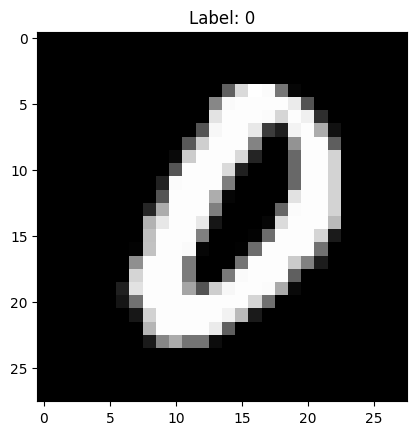

In [5]:
import matplotlib.pyplot as plt

sample_idx = torch.randint(len(mnist_train), size=(1,)).item()
img_raw, label = mnist_train[sample_idx]
plt.imshow(img_raw.squeeze(), cmap='gray')
plt.title(f'Label: {label}')
plt.show()

In [ ]:
# ToTensor, (height, width, channel) boyutlarında bir görseli/NumPy arrayi
# (channel, height, width) boyutlarında bir torch.FloatTensor e çevirir.
# Bu dönüşüm, modelin performansını arttırmaktadır.
# Ayrıca piksel değerlerini 255'e bölerek değerleri [0, 255] aralığından [0, 1] aralığına çeker.

torch.min(img_raw), torch.max(img_raw)

(tensor(0.), tensor(1.))

## Preprocessing

### Setting Up Transforms

In [ ]:
# - RandomHorizontalFlip, görseli yatay eksene göre ters çevirir.
# - RandomAffine, görseli (-10, 10) arasında bir açı değeri kadar döndürür,
#   %20 sağa-sola/yukarı-aşağı kaydırır, %10 büyültür veya küçültür.

augmentation = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomAffine(degrees=(-10, 10), translate=(0.2, 0.2), scale=(0.90, 1.1)),
])

In [8]:
# Dataset'e gerekli dönüşümleri yapmamız için bir class tanımlıyoruz.

class TransformedDataset(Dataset):
    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, idx):
        x, y = self.subset[idx]

        if self.transform:
            x = self.transform(x)
        return x, y

### Transforming the Dataset

In [9]:
# Dataset'lere dönüşümleri uyguluyoruz.
# Training dataset'e manipüle edilmiş görselleri ekliyoruz.
# Validation ve test dataset'lerini sadece scale ediyoruz.

mnist_train_augmented = TransformedDataset(mnist_train, transform=augmentation)
mnist_train = ConcatDataset([mnist_train, mnist_train_augmented])

#mnist_train = TransformedDataset(mnist_train, transform=tensor_transform)
#mnist_validation = TransformedDataset(mnist_validation, transform=tensor_transform)
#mnist_test = TransformedDataset(mnist_test, transform=tensor_transform)

print(f'Transformed training dataset size: {len(mnist_train)}')
print(f'Transformed validation dataset size: {len(mnist_validation)}')
print(f'Transformed test dataset size: {len(mnist_test)}')

Transformed training dataset size: 80000
Transformed validation dataset size: 20000
Transformed test dataset size: 10000


### Visualizing the Transformed Dataset

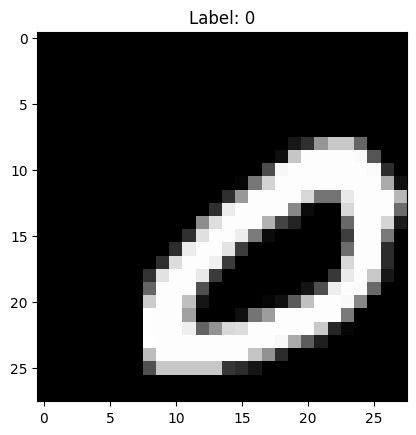

In [10]:
import matplotlib.pyplot as plt

sample_idx = torch.randint(len(mnist_train), size=(1,)).item()
img_transformed, label = mnist_train[sample_idx]
plt.imshow(img_transformed.squeeze(), cmap='gray')
plt.title(f'Label: {label}')
plt.show()

### Adding Noise

In [11]:
# Görsellere gürültü eklemek için bir fonksiyon tanımlıyoruz.

def add_noise(image, noise_factor=0.5):
    noise = torch.randn_like(image) * noise_factor
    noisy_img = image + noise

    return torch.clamp(noisy_img, 0., 1.)

### Visualizing the Noisy Images

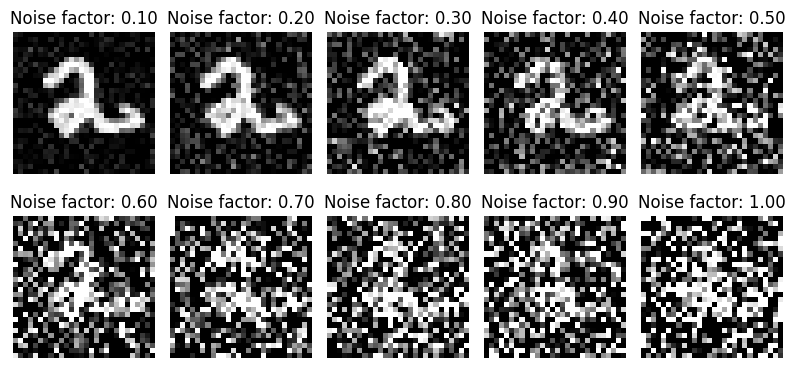

In [12]:
plt.figure(figsize=(8,4))

for idx, noise_factor in enumerate(np.linspace(0.1, 1, 10)):
  plt.subplot(2, 5, idx+1)
  img, label = mnist_train[0]

  plt.imshow(add_noise(img, noise_factor=noise_factor).squeeze(), cmap='gray')
  plt.title(f'Noise factor: {noise_factor:.2f}')
  plt.axis('off')

plt.tight_layout()
plt.show()

In [ ]:
# Dataset'i model tarafından kullanılmaya hazır hale getiriyoruz.

train_loader = DataLoader(mnist_train, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(mnist_validation, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(mnist_test, batch_size=BATCH_SIZE, shuffle=False)

80000

## Model Training / Testing

### Creating the Model

In [ ]:
# Autoencoder'ımızı tasarlıyoruz.

class DenoisingAutoencoder(torch.nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            # Girdi: [Batch, 1, 28, 28]
            nn.Conv2d(1, 16, 3, stride=2, padding=1),  # -> [Batch, 16, 14, 14]
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1), # -> [Batch, 32, 7, 7]
            nn.ReLU(),
            nn.Conv2d(32, 64, 7) # -> [Batch, 64, 1, 1] (Latent Vector)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 7), # -> [Batch, 32, 7, 7]
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # -> [Batch, 16, 14, 14]
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1), # -> [Batch, 1, 28, 28]
            nn.Sigmoid() # Piksel değerlerini 0-1 arasına çekmek için
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

### Training the Model

In [15]:
# Modeli Başlat
model = DenoisingAutoencoder().to(device)

# Loss ve Optimizer
loss = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
metrics = ['accuracy']

In [ ]:
# Epoch-loss grafikleri için saklıyoruz
train_losses = []

for epoch in range(EPOCHS):
  # Modeli training moduna alıyoruz.
  # Bunu yapmamızın sebebi PyTorch'un training ve evaluation aşamalarında farklı ayarlar kullanmasıdır.
  model.train()
  running_loss = 0.0

  for data in train_loader:
    img, _ = data
    img = img.to(device) # Görseli GPU'ya atıyoruz

    # Gürültüyü ekliyoruz
    noisy_img = add_noise(img, NOISE_FACTOR)

    # PyTorch, bir sonraki batch'e geçtikten sonra bile önceki batch'te hesapladığı gradyanları
    # saklamaya devam etmektedir. Bu sebepten dolayı yeni gradyanlar eski gradyanlara eklenecektir (accumulation).
    # Ancak bu durum, yanlış parametre güncellemelerine yol açacaktır. Bunu önlemek için önceki batch'te
    # hesaplanılan gradyanları sıfırlamamız gerekir.
    optimizer.zero_grad()

    # Gürültülü görseli encode edip sıkıştırdıktan sonra decode edip
    # görseli yeniden inşa ediyoruz (reconstruction)
    output = model(noisy_img)
    # Orijinal görsel ile reconstructed görsel arasındaki MSE'yi hesaplıyoruz
    current_loss = loss(output, img)

    # Backpropagation ile gradyanları hesaplıyoruz
    current_loss.backward()
    # Parametreleri optimizasyon yöntemimize göre güncelliyoruz (Bu durumda ADAM)
    optimizer.step()

    # O batch'teki MSE'yi ekliyoruz
    running_loss += current_loss.item()

  # O epoch için modelin ortalama başarısını hesaplıyoruz.
  # # (MSE_batch_1 + MSE_batch_2 + ... + MSE_batch_n) / n 
  epoch_train_loss = running_loss / len(train_loader)
  train_losses.append(epoch_train_loss)

  print(f"Epoch [{epoch+1}/{EPOCHS}] \t Train loss: {epoch_train_loss:.5f}")

Epoch [1/10] 	 Train Loss: 0.04407 	 Val Loss: 0.01721
Epoch [2/10] 	 Train Loss: 0.01860 	 Val Loss: 0.01376
Epoch [3/10] 	 Train Loss: 0.01620 	 Val Loss: 0.01279
Epoch [4/10] 	 Train Loss: 0.01526 	 Val Loss: 0.01235
Epoch [5/10] 	 Train Loss: 0.01479 	 Val Loss: 0.01205
Epoch [6/10] 	 Train Loss: 0.01447 	 Val Loss: 0.01183
Epoch [7/10] 	 Train Loss: 0.01424 	 Val Loss: 0.01162
Epoch [8/10] 	 Train Loss: 0.01403 	 Val Loss: 0.01152
Epoch [9/10] 	 Train Loss: 0.01390 	 Val Loss: 0.01142
Epoch [10/10] 	 Train Loss: 0.01378 	 Val Loss: 0.01134


### Validating the Model

In [ ]:
# Modeli validasyon dataseti ile test ediyoruz ki elde ettiğimiz sonuçlara göre
# modelin hiperparametrelerini güncelleyelim.

# Epoch-loss grafikleri için saklıyoruz
val_losses = []

for epoch in range(EPOCHS):

  # Modeli evaluation moduna alıyoruz
  model.eval()
  running_val_loss = 0.0

  # Modele gradyan hesaplamamasını söylüyoruz
  with torch.no_grad():
      for data in val_loader:
          img, _ = data

          # Görseli GPU'ya atıyoruz
          img = img.to(device)

          # Görsele gürültü ekliyoruz
          noisy_img = add_noise(img, NOISE_FACTOR)

          # Görsele "denoise" uyguluyoruz
          output = model(noisy_img)

          # MSE hesaplıyoruz yine
          current_loss = loss(output, img)
          running_val_loss += current_loss.item()

  # Epoch başı modelin ortalama başarısını hesaplıyoruz
  epoch_val_loss = running_val_loss / len(val_loader)
  val_losses.append(epoch_val_loss)

  print(f"Epoch [{epoch+1}/{EPOCHS}] \t Validation loss: {epoch_val_loss:.5f}")

### Plotting the Training and Validation Losses

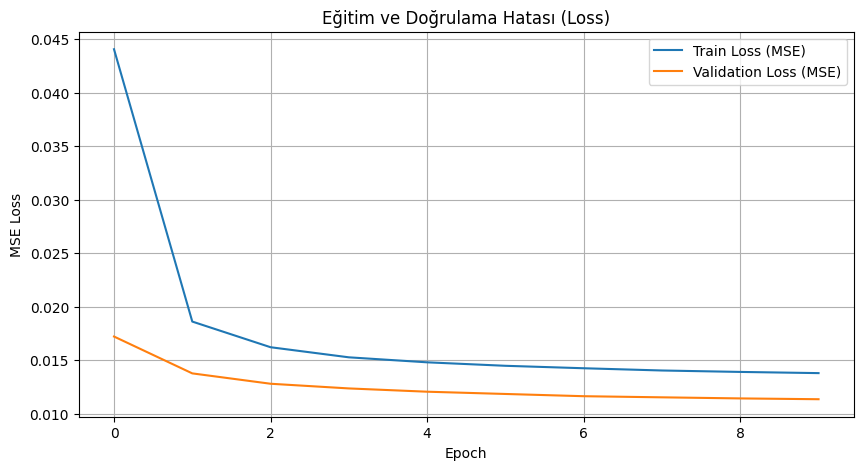

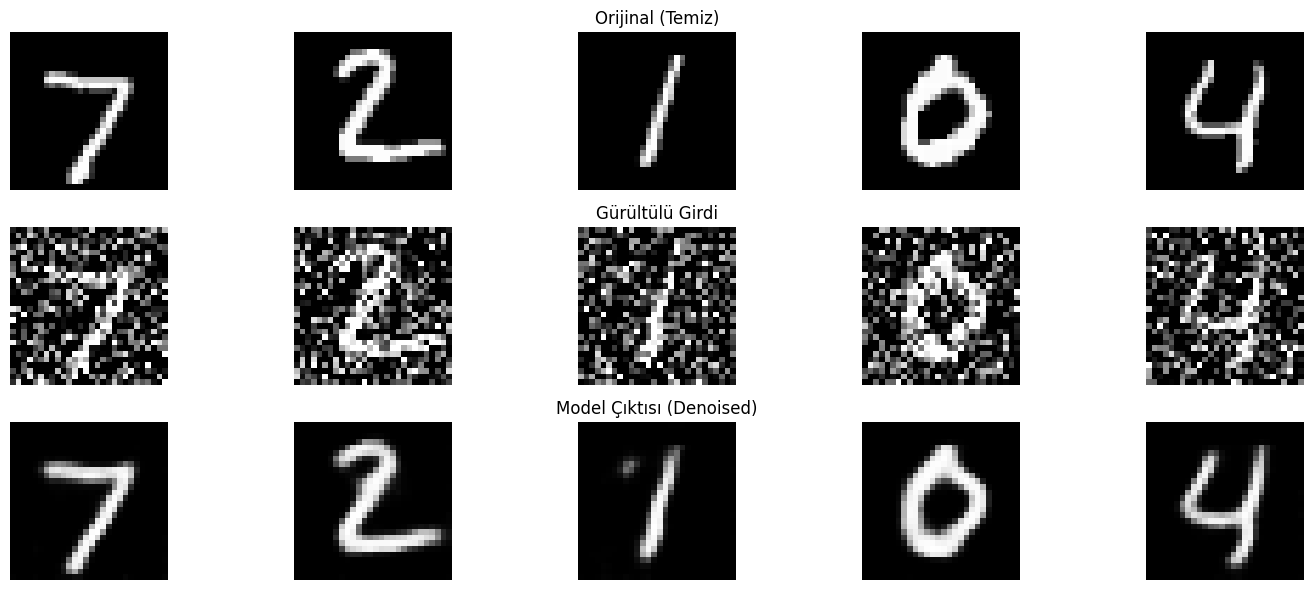


Test Seti Ortalama PSNR Değeri: 19.56 dB
(Not: 30 dB üzeri genellikle iyi kabul edilir.)


In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss (MSE)')
plt.plot(val_losses, label='Validation Loss (MSE)')
plt.title('Comparison Between Training and Validation Losses')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.grid(True)
plt.show()

### Testing the Model

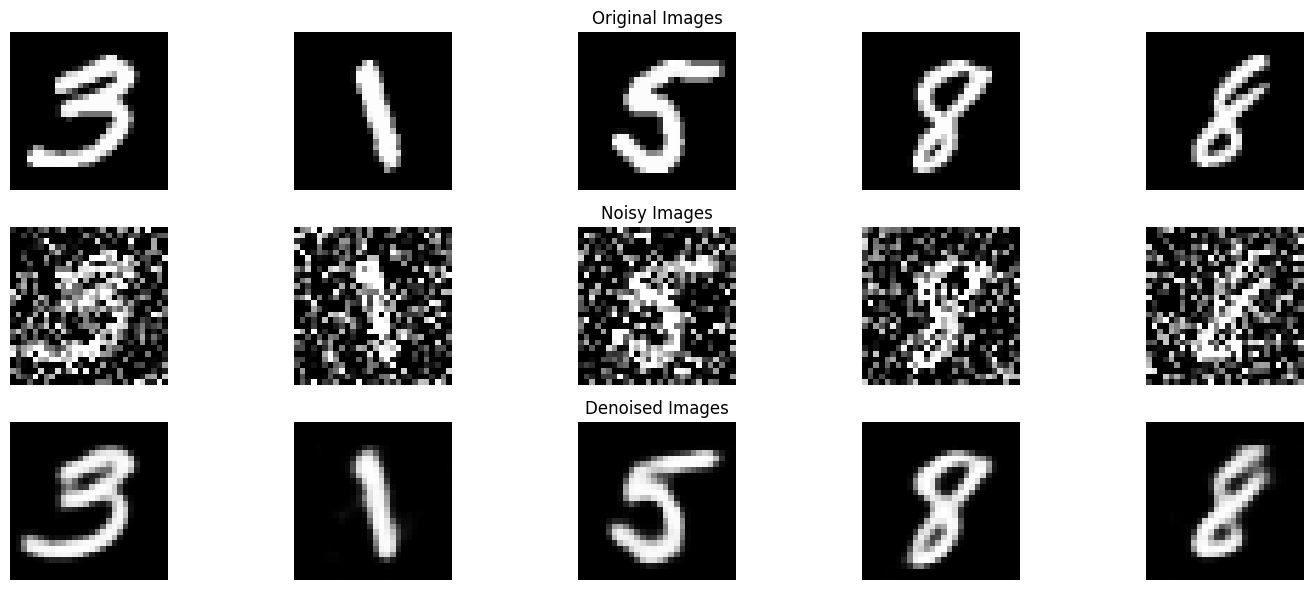

In [34]:
def visualize_results(model, dataset, num_images=5):
    # Modeli evaluation moduna alıyoruz
    model.eval()
    
    # num_images kadar görseli alıyoruz
    temp_loader = DataLoader(dataset, batch_size=num_images, shuffle=True)
    images, _ = next(iter(temp_loader))
    images = images.to(device)

    # Görsellere gürültü ekliyoruz
    noisy_images = add_noise(images, NOISE_FACTOR)

    # Gürültülü görseli "denoise" ediyoruz
    with torch.no_grad():
        outputs = model(noisy_images)

    # Görselleri CPU'ya alıyoruz ve numpy array'e çeviriyoruz
    images = images.cpu().numpy()
    noisy_images = noisy_images.cpu().numpy()
    outputs = outputs.cpu().numpy()

    # Görselleri plotluyoruz
    fig, axes = plt.subplots(3, num_images, figsize=(15, 6))
    plt.gray()

    # 1. satırda orijinal görseller
    # 2. satırda gürültülü görseller
    # 3. satırda denoise edilmiş görseller
    for i in range(num_images):

        # i. sütun 1. satır
        axes[0, i].imshow(images[i].reshape(28, 28))
        axes[0, i].axis('off')
        # Ortadaki görselin üstünde başlık
        if i == num_images // 2: axes[0, i].set_title("Original Images")

        # i. sütun 2. satır
        axes[1, i].imshow(noisy_images[i].reshape(28, 28))
        axes[1, i].axis('off')
        if i == num_images // 2: axes[1, i].set_title("Noisy Images")

        # i. sütun 3. satır
        axes[2, i].imshow(outputs[i].reshape(28, 28))
        axes[2, i].axis('off')
        if i == num_images // 2: axes[2, i].set_title("Denoised Images")

    plt.tight_layout()
    plt.show()

visualize_results(model, mnist_test)